In [1]:
#cell1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
#cell2
df = pd.read_csv('PS_20174392719_1491204439457_log.csv')
print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
None

Class Distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


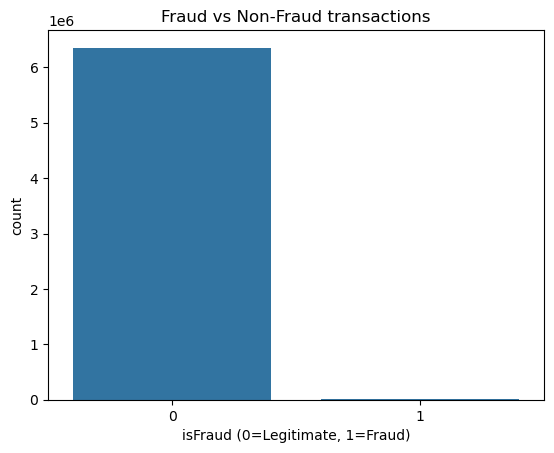

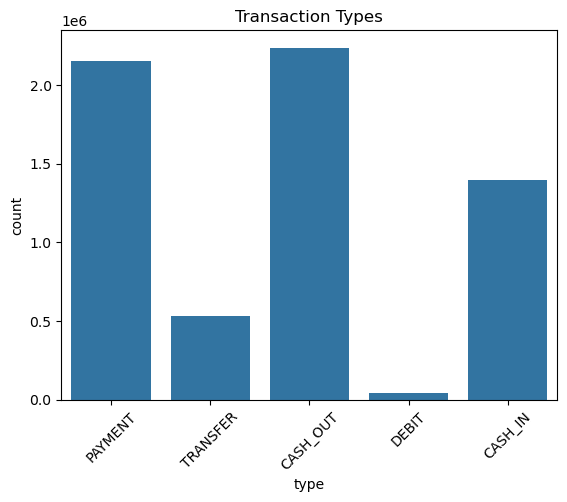

<Figure size 640x480 with 0 Axes>

In [3]:
# cell3 :Exploratory data analysis , i am using this to understand my data set
print(df.info())
print("\nClass Distribution:")
print(df['isFraud'].value_counts())

import matplotlib.pyplot as plt
import seaborn as sns

#plotclass distribution
sns.countplot(x='isFraud', data=df)
plt.title('Fraud vs Non-Fraud transactions')
plt.xlabel('isFraud (0=Legitimate, 1=Fraud)')
plt.ylabel('count')
plt.savefig('fraud_vs_legit.png', dpi=300, bbox_inches='tight') 
plt.show()

#Transaction type distribution
sns.countplot(x='type', data=df)
plt.title('Transaction Types')
plt.xticks(rotation=45)
plt.show()
plt.savefig('Transaction Types.png', dpi=300, bbox_inches='tight') 

In [4]:
#cell4 :from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

#checking formissing values ,blank or empty spaces
print("Missing Values:", df.isnull().sum())

# droppingcolumn we dont need for traing the model
df=df.drop(['nameOrig','nameDest','isFlaggedFraud'], axis=1)

#encoding the column word to numbers since MODELS only understand numbers.
le= LabelEncoder()
df['type']=le.fit_transform(df['type'])

#seperate the features and  target
x=df.drop('isFraud',axis=1)
y=df['isFraud']

print("preprocessing sucessful")
print(df.shape)

Missing Values: step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64
preprocessing sucessful
(6362620, 8)


In [5]:
# cell5 :from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Train/Test Split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y)

# Scale first
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print("Before SMOTE:")
print(pd.Series(y_train).value_counts())

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train).value_counts())
print("\nNew training size:", x_train.shape)

Before SMOTE:
isFraud
0    5083526
1       6570
Name: count, dtype: int64

After SMOTE:
isFraud
0    5083526
1    5083526
Name: count, dtype: int64

New training size: (10167052, 7)


In [6]:
# Cell 6 - Train the 3 Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model 1 - Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)
print("Logistic Regression done!")

# Model 2 - Random Forest
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
print("Random Forest done!")

# Model 3 - XGBoost
print("Training XGBoost...")
xgb = XGBClassifier(n_estimators=100, random_state=42)
xgb.fit(x_train, y_train)
print("XGBoost done!")

print("All models trained successfully!")

Training Logistic Regression...
Logistic Regression done!
Training Random Forest...
Random Forest done!
Training XGBoost...
XGBoost done!
All models trained successfully!


In [11]:
#cell 0 -reloading model to avoid run cell 6 again
import joblib
import numpy as np
#loading all three models
xgb = joblib.load("fraud_model.pkl")
lr = joblib.load("logistic_regression_model.pkl")
rf = joblib.load("random_forest_model.pkl")
scalar = joblib.load("scaler.pkl")

# reloading test data
x_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")
print ("All three models and scalar and test data loaded successfuly")
print("test data shape: ", x_test.shape)

All three models and scalar and test data loaded successfuly
test data shape:  (1272524, 7)


In [12]:
# cell 7 :model evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# for logistic regression
print("===Logistic Regression ===")
lr_pred=lr.predict(x_test)
print(classification_report(y_test,lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(x_test)[:,1]))

#for Randomforest
print("=== Random Forest ===")
rf_pred=rf.predict(x_test)
print(classification_report(y_test,rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(x_test)[:,1]))

#for xgboost
print("=== XGBoost ===")
xgb_pred=xgb.predict(x_test)
print(classification_report(y_test,xgb_pred))
print("ROC-AUC:",roc_auc_score(y_test,xgb.predict_proba(x_test)[:,1]))


===Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270881
           1       0.03      0.88      0.06      1643

    accuracy                           0.96   1272524
   macro avg       0.52      0.92      0.52   1272524
weighted avg       1.00      0.96      0.98   1272524

ROC-AUC: 0.9770031388546786
=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.63      0.96      0.76      1643

    accuracy                           1.00   1272524
   macro avg       0.82      0.98      0.88   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC: 0.998945951910846
=== XGBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.35      0.99      0.51      1643

    accuracy                           1.00   1272524
   macro

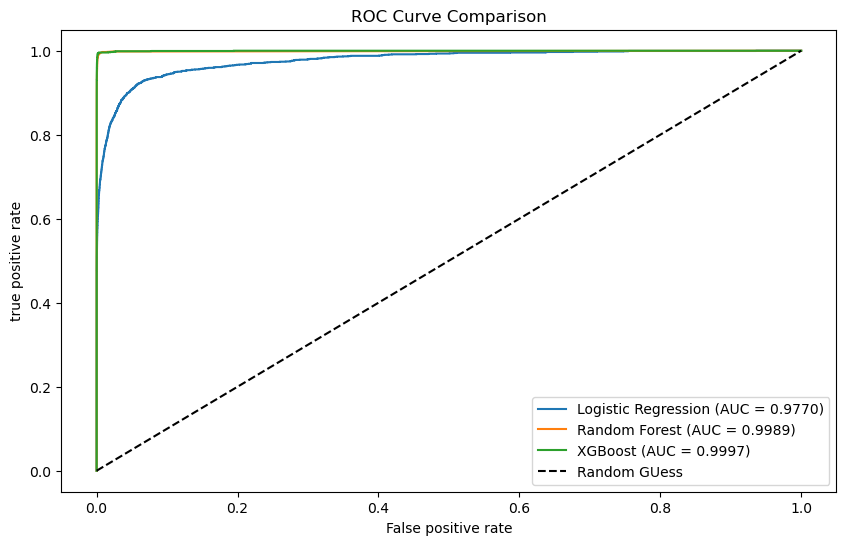

In [15]:
#cell8: ROC curve comparism of each of the models
from sklearn.metrics import roc_curve,auc
plt.figure(figsize=(10,6))

#logisticregreesion model
lr_fpr, lr_tpr, _=roc_curve(y_test, lr.predict_proba(x_test)[:,1])
plt.plot(lr_fpr, lr_tpr, label='Logistic Regression (AUC = 0.9770)')

#for randomforest roc
rf_fpr, rf_tpr, _=roc_curve(y_test, rf.predict_proba(x_test)[:,1])
plt.plot(rf_fpr, rf_tpr, label='Random Forest (AUC = 0.9989)')

#for xgboostroc
xgb_fpr,xgb_tpr,_=roc_curve(y_test,xgb.predict_proba(x_test)[:,1])
plt.plot(xgb_fpr, xgb_tpr, label='XGBoost (AUC = 0.9997)')

#diagonalrefrence line 
plt.plot([0,1],[0,1], "k--", label="Random GUess")
plt.xlabel("False positive rate")
plt.ylabel("true positive rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.savefig('Roc Curve comparison.png', dpi=300, bbox_inches='tight') 
plt.show()


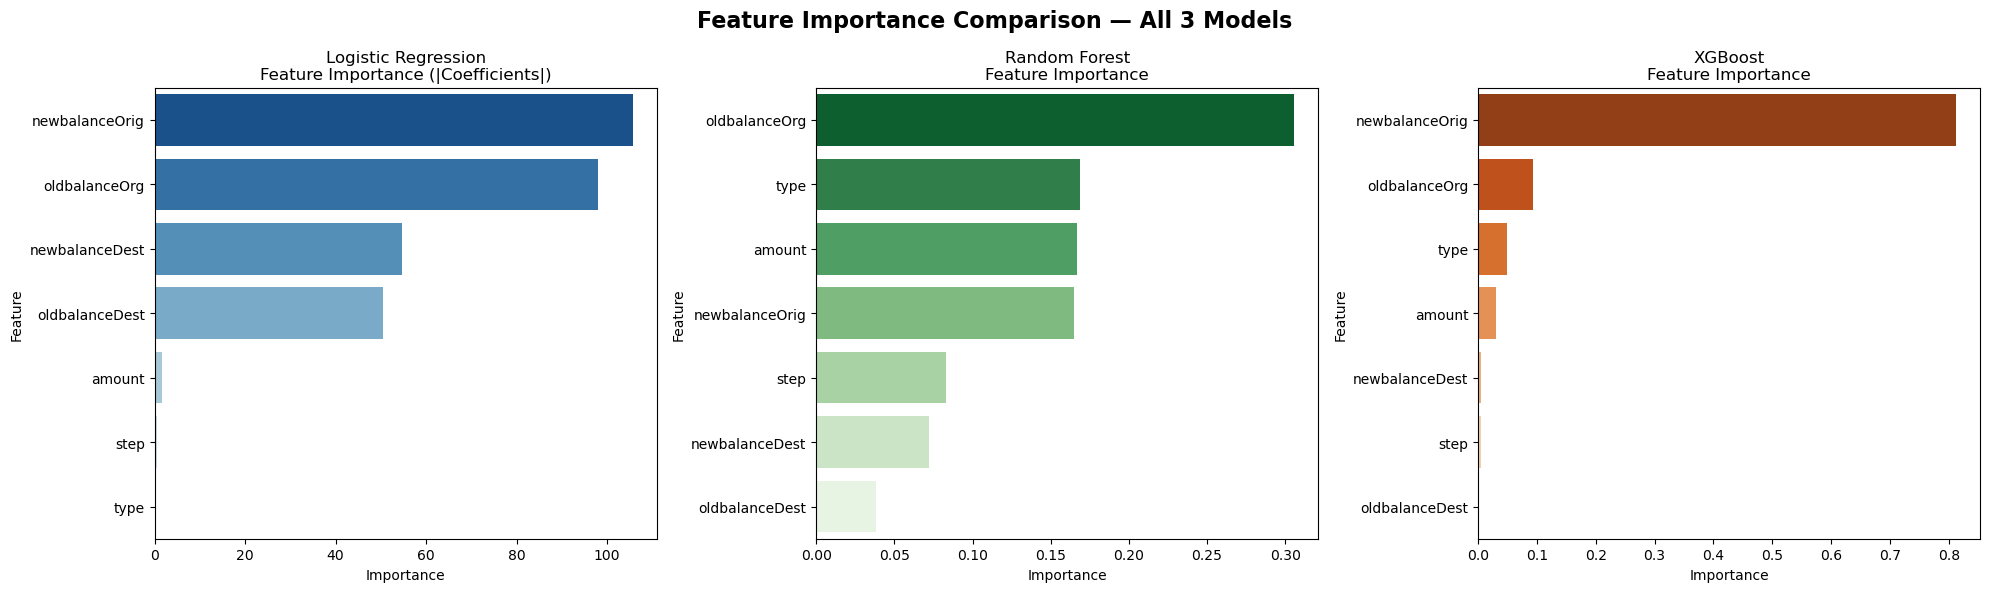


Logistic Regression:
        Feature  Importance
newbalanceOrig  105.684392
 oldbalanceOrg   97.914025
newbalanceDest   54.593669
oldbalanceDest   50.388596
        amount    1.569718
          step    0.422746
          type    0.043685

Random Forest:
        Feature  Importance
 oldbalanceOrg    0.305856
          type    0.168737
        amount    0.167053
newbalanceOrig    0.164773
          step    0.083033
newbalanceDest    0.072198
oldbalanceDest    0.038351

XGBoost:
        Feature  Importance
newbalanceOrig    0.812068
 oldbalanceOrg    0.094273
          type    0.049449
        amount    0.031306
newbalanceDest    0.005377
          step    0.005183
oldbalanceDest    0.002344


In [13]:
# Cell 9 - Feature Importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

feature_names = ['step', 'type', 'amount',
                 'oldbalanceOrg', 'newbalanceOrig',
                 'oldbalanceDest', 'newbalanceDest']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Logistic Regression --------------------
lr_importance = np.abs(lr.coef_[0])
lr_df = pd.DataFrame({'Feature': feature_names, 'Importance': lr_importance})\
          .sort_values('Importance', ascending=False)
sns.barplot(x='Importance', y='Feature', data=lr_df, ax=axes[0], palette='Blues_r',hue='Feature', legend=False)
axes[0].set_title('Logistic Regression\nFeature Importance (|Coefficients|)')

# --- Random Forest ---------------------
rf_importance = rf.feature_importances_
rf_df = pd.DataFrame({'Feature': feature_names, 'Importance': rf_importance})\
          .sort_values('Importance', ascending=False)
sns.barplot(x='Importance', y='Feature', data=rf_df, ax=axes[1], palette='Greens_r',hue='Feature', legend=False)
axes[1].set_title('Random Forest\nFeature Importance')

# --- XGBoost -----------------------
xgb_importance = xgb.feature_importances_
xgb_df = pd.DataFrame({'Feature': feature_names, 'Importance': xgb_importance})\
           .sort_values('Importance', ascending=False)
sns.barplot(x='Importance', y='Feature', data=xgb_df, ax=axes[2], palette='Oranges_r',hue='Feature', legend=False)
axes[2].set_title('XGBoost\nFeature Importance')

plt.suptitle('Feature Importance Comparison — All 3 Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('Feature Importance Comparison--All three Models.png', dpi=300, bbox_inches='tight') 
plt.show()

print("\nLogistic Regression:\n", lr_df.to_string(index=False))
print("\nRandom Forest:\n", rf_df.to_string(index=False))
print("\nXGBoost:\n", xgb_df.to_string(index=False))

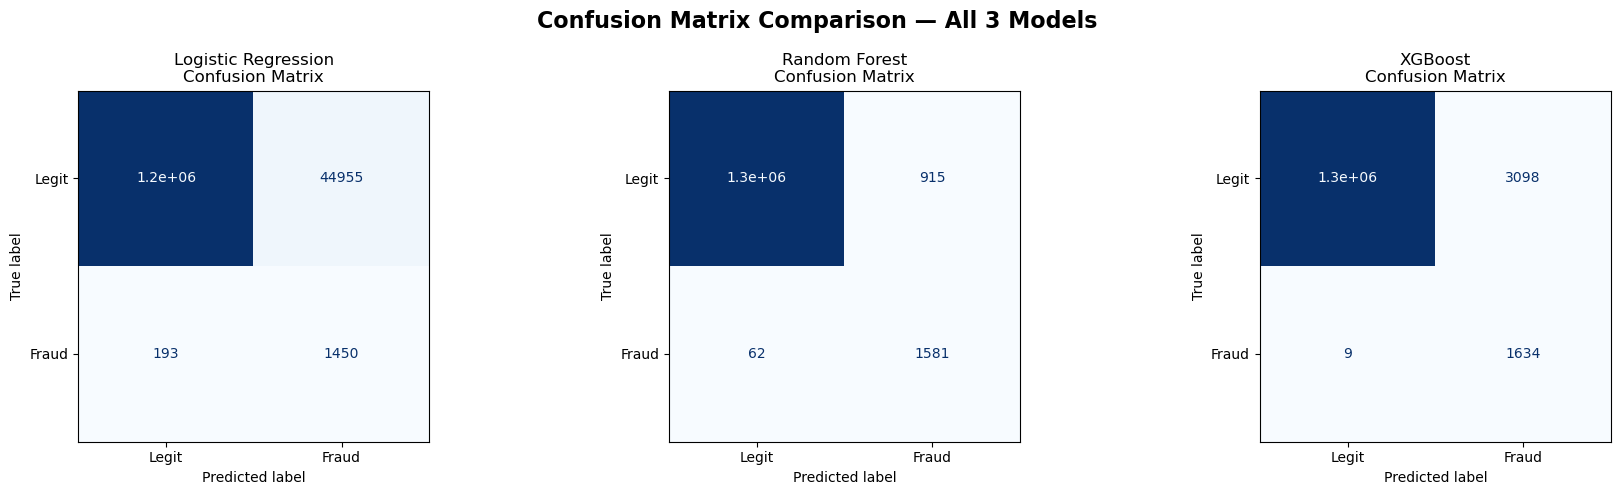

In [14]:
#cell10 :confusion matrixs
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    (lr, lr_pred, 'Logistic Regression'),
    (rf, rf_pred, 'Random Forest'),
    (xgb, xgb_pred, 'XGBoost'),
]

for ax, (model, pred, name) in zip(axes, models):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nConfusion Matrix')

plt.suptitle('Confusion Matrix Comparison — All 3 Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('Confusion Matrix Comparison — All three Models.png', dpi=300, bbox_inches='tight') 
plt.show()




In [15]:
#cell 11 :import joblib

# Saving all the model and scaler
joblib.dump(xgb, 'fraud_model.pkl')
joblib.dump(lr, 'logistic_regression_model.pkl')
joblib.dump(rf, 'random_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Save test data
import numpy as np
np.save('X_test.npy', x_test)
np.save('y_test.npy', y_test)

print(" All Model, scaler and test data saved successfully!")

 All Model, scaler and test data saved successfully!
